# DeepLense Task I

In [17]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [18]:
# Import packages
import numpy as np
import torch
from torch import nn
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from pathlib import Path
import matplotlib.pyplot as plt

## Dataset

The Dataset consists of three classes, strong lensing images with no substructure, subhalo substructure, and vortex substructure. The images have been normalized using min-max normalization, but you are free to use any normalization or data augmentation methods to improve your results.

In [19]:
# Download provided dataset
# !gdown "https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ" -O dataset_test_I.zip
# !unzip dataset_test_I.zip & rm dataset_test_I.zip

In [20]:
# Dataset class
class DeepLenseDataset(Dataset):

    CLASS_NAMES = ["no", "sphere", "vort"]

    def __init__(self, path: Path, transform: transforms.Compose = None):

        self.root = path
        self.samples = []
        self.idx_to_class = {i: name for i, name in enumerate(self.CLASS_NAMES)}
        self.transform = transform

        for class_idx, class_name in enumerate(self.CLASS_NAMES):
            class_dir = self.root / class_name
            paths = class_dir.glob("*.npy")
            self.samples.extend((p, class_idx) for p in paths)

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> tuple[Tensor, int]:
        path, label = self.samples[idx]
        arr = np.load(path)
        x = torch.from_numpy(arr).float()
        x = x.repeat(3, 1, 1)
        if self.transform:
            x = self.transform(x)
        return x, label


In [21]:
# Load datasets
train_dataset = DeepLenseDataset(path=Path("dataset_test_I/train"))
test_dataset = DeepLenseDataset(path=Path("dataset_test_I/val"))


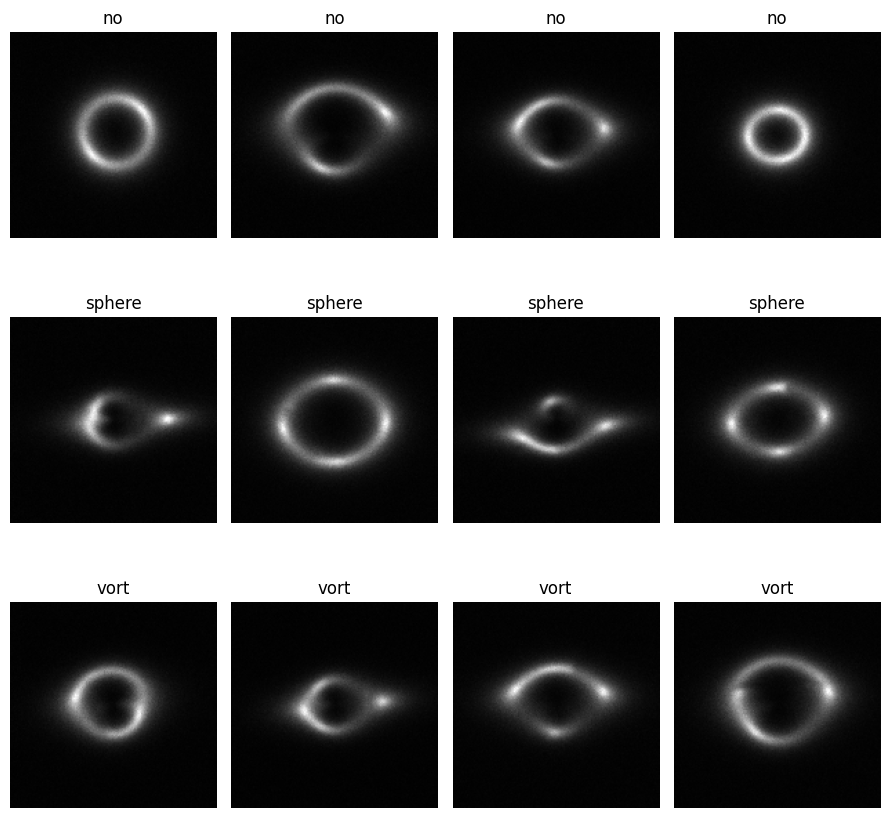

In [22]:
def plot_sample(x, y, figsize=(4, 4)):
    """
    Plot a sample from the dataset.
    """
    img = x.squeeze().detach().cpu().numpy()
    img = np.transpose(img, (1, 2, 0))
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f"label={y}")
    plt.show()

def inspect_dataset(dataset: DeepLenseDataset):
    """
    Iterate over the dataset and plot 4 samples for each class.
    """

    count = {}
    count_total = 0

    fig, axs = plt.subplots(3, 4, figsize=(9, 9))
    axs = axs.flatten()

    for i in range(len(dataset)):

        x, y = dataset[i]

        if count.get(y, 0) < 4:
            img = img = x.squeeze().detach().cpu().numpy()
            img = np.transpose(img, (1, 2, 0))
            axs[count_total].imshow(img)
            axs[count_total].set_title(dataset.idx_to_class[y])
            axs[count_total].axis("off")
            count[y] = count.get(y, 0) + 1
            count_total += 1
    
    plt.tight_layout()
    plt.show()

# Visualize some samples
inspect_dataset(train_dataset)

[10000, 10000, 10000]


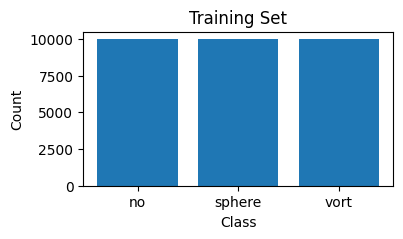

[2500, 2500, 2500]


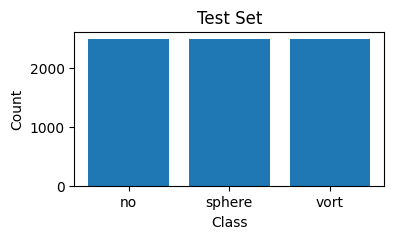

In [23]:
def plot_class_distribution(dataset, title="Class Distribution"):
    """
    Plot dataset class distribution.
    """
    labels = [dataset.idx_to_class[i] for i in range(len(dataset.idx_to_class))]
    counts = [0] * len(labels)
    for _, y in dataset:
        counts[y] += 1

    print(counts)

    plt.figure(figsize=(4,2))
    plt.bar(labels, counts)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title(title)
    plt.show()

# Plot class distribution
plot_class_distribution(train_dataset, "Training Set")
plot_class_distribution(test_dataset, "Test Set")

We can see that the dataset is balanced.

In [24]:
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

def stratified_split(dataset, transform=None, train_size=0.8):

    # Get labels
    labels = [label for _, label in dataset]

    # Stratified split
    train_indices, val_indices = train_test_split(
        np.arange(len(labels)),
        train_size=train_size,
        stratify=labels,
        random_state=42
    )

    # Create train and val datasets
    # Augmentation is applied to training dataset only
    train_ds = DeepLenseDataset(path=dataset.root, transform=transform)
    val_ds = DeepLenseDataset(path=dataset.root, transform=None)
    train_dataset = Subset(train_ds, train_indices)
    val_dataset = Subset(val_ds, val_indices)

    return train_dataset, val_dataset

## Dataloader

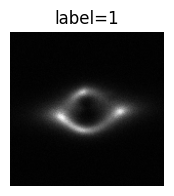

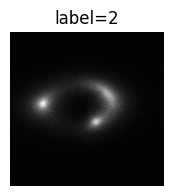

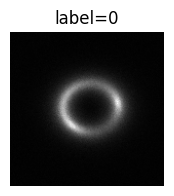

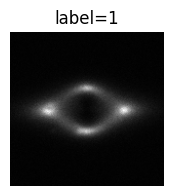

In [25]:
# Create dataloader
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# Iterate over the dataloader
for x, y in train_dataloader:
    for i in range(x.shape[0]):
        plot_sample(x[i], y[i], figsize=(2, 2))
    break


## Training

- I am using PyTorch Lightning for training to avoid writing standard boilerplate code.

- I am using data from "train" folder for training and validation, "val" folder will be used for reporting final results.

- The base training pipeline for this task is straightforward:

  - Resnet18
  - Cross Entropy Loss
  - Adam optimizer
  - ReduceLROnPlateau (if validation loss doesn't improve by 5 epochs)
  - Early Stopping (if validation loss doesn't improve by 10 epochs)
  - Save best checkpoint based on validation loss

- To allow for rapid iteration, I will use small models. The models are imported from torchvision with weights pretrained on ImageNet and final layer is modified to match the required number of classes.

- Experimental results:

  | Name | val_loss | val_auroc_no | val_auroc_sphere | val_auroc_vort | val_acc_no | val_acc_sphere | val_acc_vort |
  | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
  | resnet18          | 0.2810 | 0.9885 | 0.9678 | 0.9865 | 0.9668 | 0.8772 | 0.9228 |
  | resnet18 + affine | 0.1344 | 0.9962 | 0.9850 | 0.9945 | 0.9999 | 0.8780 | 0.9715 |
  | resnet18 + affine + noise (0.01) | 0.2457 | 0.9878 | 0.9570 | 0.9777 | 0.9970 | 0.8210 | 0.9090 |

    
  <b>Train Loss</b><br><img src="images/test_I_train_loss.png" alt="train loss" width="800"/>

  <b>Validation Loss</b><br><img src="images/test_I_val_loss.png" alt="val loss" width="800"/>    
    

In [26]:
import torchmetrics
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

class DeepLenseModel(pl.LightningModule):

    def __init__(self, lr=0.001, num_classes=3):

        super().__init__()
        self.lr = lr
        self.loss_fn = nn.CrossEntropyLoss()
        self.model = models.resnet18(weights="DEFAULT")
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

        # Metrics
        self.accuracy = torchmetrics.classification.MulticlassAccuracy(num_classes=num_classes, average=None)
        self.auroc = torchmetrics.classification.MulticlassAUROC(num_classes=num_classes, average=None)
        self.roc = torchmetrics.classification.MulticlassROC(num_classes=num_classes, average=None)
        self.cm = torchmetrics.classification.MulticlassConfusionMatrix(num_classes=num_classes)

    def forward(self, x):
        return self.model(x).squeeze(-1)

    # Run every training step
    def training_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.loss_fn(preds, y.float())
        self.log("train_loss", loss, prog_bar=True)
        return loss

    # Run every validation step
    def validation_step(self, batch, batch_idx):
        x, y = batch
        preds = self(x)
        loss = self.loss_fn(preds, y.float())

        probs = torch.sigmoid(preds)
        self.auroc(probs, y)
        self.roc(probs, y)
        self.accuracy(probs, y)
        self.cm(probs, y)

        self.log("val_loss", loss, prog_bar=True)

        return loss

    # Run after validation
    def on_validation_epoch_end(self):
        if self.trainer.sanity_checking:
            return

        # Compute per class ROC
        fprs, tprs, thresholds = self.roc.compute()
        self.last_fprs = fprs
        self.last_tprs = tprs
        self.roc.reset()
        
        # Compute per class metrics
        accuracy = self.accuracy.compute()
        auroc = self.auroc.compute()

        for class_idx, class_name in enumerate(DeepLenseDataset.CLASS_NAMES):
            self.log(f"val_acc_{class_name}", accuracy[class_idx], prog_bar=True, on_epoch=True)
            self.log(f"val_auroc_{class_name}", auroc[class_idx], prog_bar=True, on_epoch=True)

        # Compute confusion matrix
        self.confusion_matrix = self.cm.compute().detach().cpu()
        self.cm.reset()

        # Reset metrics
        self.auroc.reset()
        self.accuracy.reset()

    def configure_optimizers(self):

        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.1,
            patience=5
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1
            }
        }

# Augmentations
def add_per_channel_noise(tensor):
    noise = torch.randn_like(tensor) * 0.01
    return tensor + noise

transform = transforms.Compose([
    transforms.Lambda(add_per_channel_noise),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomAffine(degrees=45, translate=(0.1, 0.1), scale=(0.9, 1.1)),
])

# Initialize dataloaders
BATCH_SIZE = 128

# Split dataset into train and validation
dataset = DeepLenseDataset(path=Path("dataset_test_I/train"))
train_dataset, val_dataset = stratified_split(dataset, train_size=0.8, transform=transform)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Initialize model
model = DeepLenseModel()

# Train
logger = TensorBoardLogger(
    save_dir="logs",
    name="test_I",
    version="resnet18 + affine + noise (0.1)"
)

trainer = pl.Trainer(
    max_epochs=60,
    accelerator="auto",
    logger=logger,
    callbacks=[
        # Save the best model based on validation loss
        ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1),
        # Stop training if validation loss does not improve for 10 epochs
        EarlyStopping(monitor="val_loss", patience=10, mode="min")
    ]
)

# Uncomment to train
# trainer.fit(model, train_dataloader, val_dataloader)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
# Print results for best model on validation data
val_results = trainer.validate(model, val_dataloader, ckpt_path="best")

## Test

- Following good practices in Machine Learning, this step is performed once after selecting the best model. This way, we avoid overfitting to the test data.

In [27]:
test_dataset = DeepLenseDataset(path=Path("dataset_test_I/val"))
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
ckpt_path = "weights/test_I_best_model.ckpt"
test_results = trainer.validate(model, test_dataloader, ckpt_path=ckpt_path)


Restoring states from the checkpoint path at weights/test_I_best_model.ckpt
/Users/lucaspimentel/Projects/ml4sci_gsoc/.venv/lib/python3.13/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:566: The dirpath has changed from 'logs/test_I/resnet18 + affine/checkpoints' to 'logs/test_I/resnet18 + affine + noise (0.1)/checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last_model_path` and `best_k_models` won't be reloaded. Only `best_model_path` will be reloaded.
Loaded model weights from the checkpoint at weights/test_I_best_model.ckpt
/Users/lucaspimentel/Projects/ml4sci_gsoc/.venv/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/lucaspimentel/Projects/ml4sci_gsoc/.venv/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many worker

Validation DataLoader 0:   2%|▏         | 1/59 [00:00<00:27,  2.13it/s]

/Users/lucaspimentel/Projects/ml4sci_gsoc/.venv/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No negative samples in targets, false positive value should be meaningless. Returning zero tensor in false positive score
  warnings.warn(*args, **kwargs)
/Users/lucaspimentel/Projects/ml4sci_gsoc/.venv/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)


Validation DataLoader 0: 100%|██████████| 59/59 [00:11<00:00,  5.32it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       val_acc_no           0.9980000257492065
     val_acc_sphere         0.8820000290870667
      val_acc_vort          0.9764000177383423
      val_auroc_no          0.9946352243423462
    val_auroc_sphere        0.9820775985717773
     val_auroc_vort         0.9951322078704834
        val_loss            0.13783976435661316
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


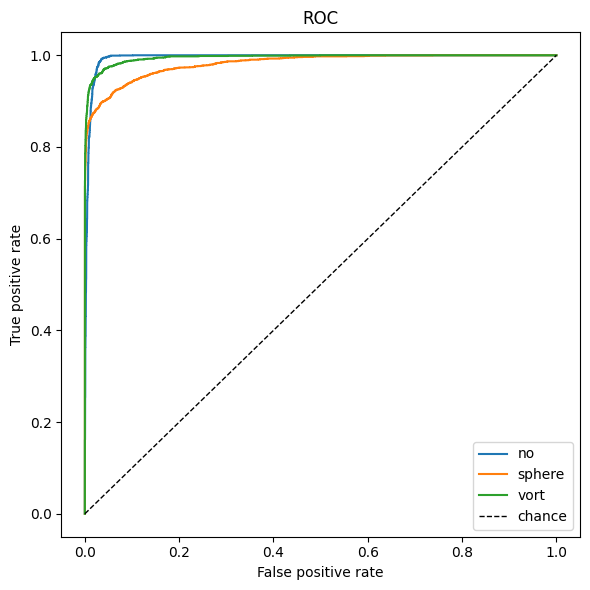

In [28]:
def plot_roc(model):

    # Get ROC results
    fprs = model.last_fprs
    tprs = model.last_tprs

    # Get class names
    names = DeepLenseDataset.CLASS_NAMES  

    # Plot curves
    plt.figure(figsize=(6, 6))
    for i, name in enumerate(names):
        plt.plot(
            np.asarray(fprs[i].cpu()).ravel(),
            np.asarray(tprs[i].cpu()).ravel(),
            label=name,
        )
        
    plt.plot([0, 1], [0, 1], "k--", lw=1, label="chance")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

plot_roc(model)

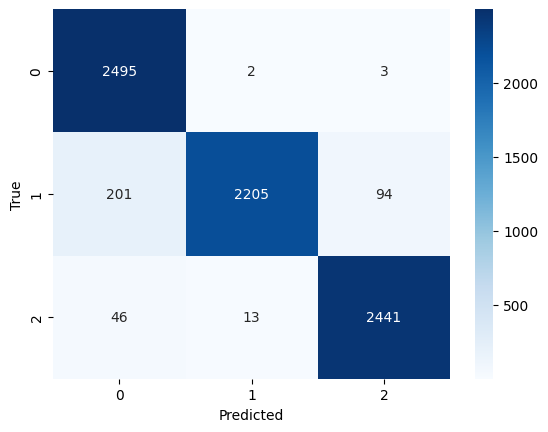

In [29]:
import seaborn as sns

def plot_confusion_matrix(model):
    sns.heatmap(model.confusion_matrix, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    
plot_confusion_matrix(model)